# Nigeria House Price Prediction – My Second Project

**Goal**: Predict house prices in Nigeria and identify key factors (bedrooms, location, etc.).

**Dataset**: Nigeria Houses and Prices (Kaggle) – real estate listings across states.

**Skills**: EDA, visualization, regression modeling and simple predictive modeling.

In [1]:
from google.colab import files
uploaded = files.upload()

Saving nigeria_houses_data.csv to nigeria_houses_data.csv


In [2]:
import pandas as pd
import io

filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

print("Shape:", df.shape)
df.head()
df.info()

Shape: (24326, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24326 entries, 0 to 24325
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   bedrooms       24326 non-null  float64
 1   bathrooms      24326 non-null  float64
 2   toilets        24326 non-null  float64
 3   parking_space  24326 non-null  float64
 4   title          24326 non-null  object 
 5   town           24326 non-null  object 
 6   state          24326 non-null  object 
 7   price          24326 non-null  float64
dtypes: float64(5), object(3)
memory usage: 1.5+ MB


In [3]:
# Check missing values
print(df.isnull().sum())

# Fill or drop missing (example – adjust based on your data)
df = df.dropna()  # or fill with mean/median for numeric

# Convert price to numeric if needed (strip ₦ or commas)
df['price'] = pd.to_numeric(df['price'].replace('[\₦,]', '', regex=True), errors='coerce')

# Basic stats
df.describe()

bedrooms         0
bathrooms        0
toilets          0
parking_space    0
title            0
town             0
state            0
price            0
dtype: int64


,bedrooms,bathrooms,toilets,parking_space,price
count,24326.000000,24326.000000,24326.000000,24326.000000,2.432600e+04
mean,4.338814,4.600798,5.176355,4.041725,3.013802e+08
std,1.138497,1.163161,1.226253,1.399936,1.220403e+10
min,1.000000,1.000000,1.000000,1.000000,9.000000e+04
25%,4.000000,4.000000,5.000000,4.000000,5.200000e+07
50%,4.000000,5.000000,5.000000,4.000000,8.500000e+07
75%,5.000000,5.000000,6.000000,4.000000,1.600000e+08
max,9.000000,9.000000,9.000000,9.000000,1.800000e+12


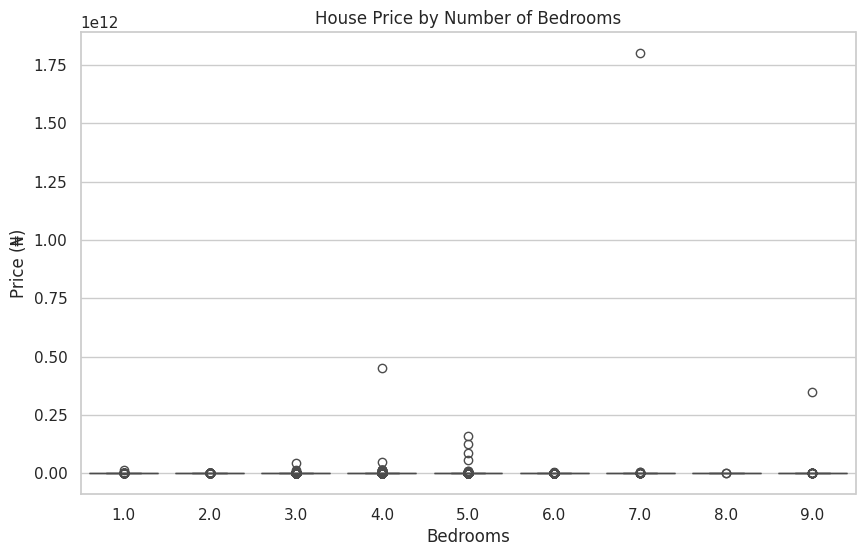

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.boxplot(x='bedrooms', y='price', data=df)
plt.title('House Price by Number of Bedrooms')
plt.xlabel('Bedrooms')
plt.ylabel('Price (₦)')
plt.show()

### Insight: Price by Bedrooms
- Houses with more bedrooms tend to have higher prices (upward trend in boxplot).
- Outliers in high-bedroom houses (luxury properties?).
- Recommendation: Location and size drive value more than just bedrooms.

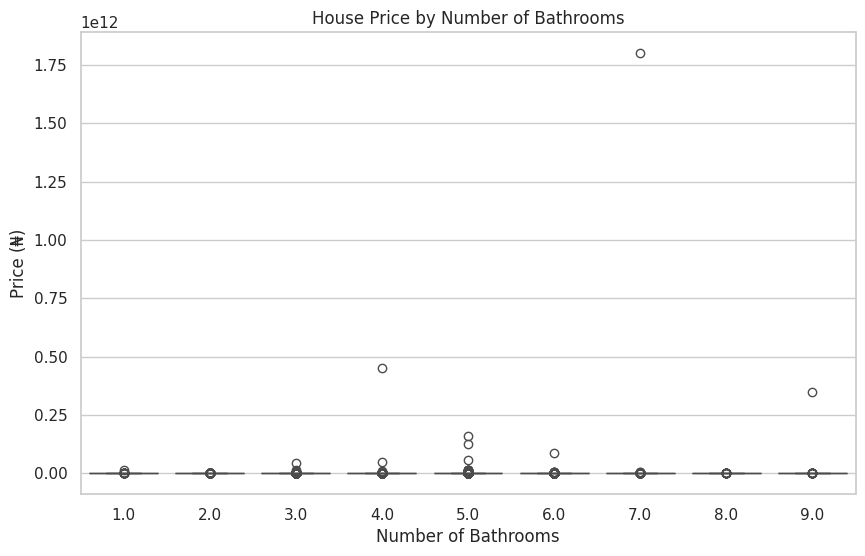

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.boxplot(x='bathrooms', y='price', data=df)
plt.title('House Price by Number of Bathrooms')
plt.xlabel('Number of Bathrooms')
plt.ylabel('Price (₦)')
plt.show()

### Insight: Price by Number of Bathrooms
- Houses with more bathrooms tend to command higher prices (upward trend in the boxplot medians).
- There are noticeable outliers (very expensive houses) even with fewer bathrooms — likely luxury properties in prime locations.
- **Business takeaway**: Bathrooms are a strong value driver; developers could prioritize 3+ bathrooms in mid-to-high-end builds to maximize returns.

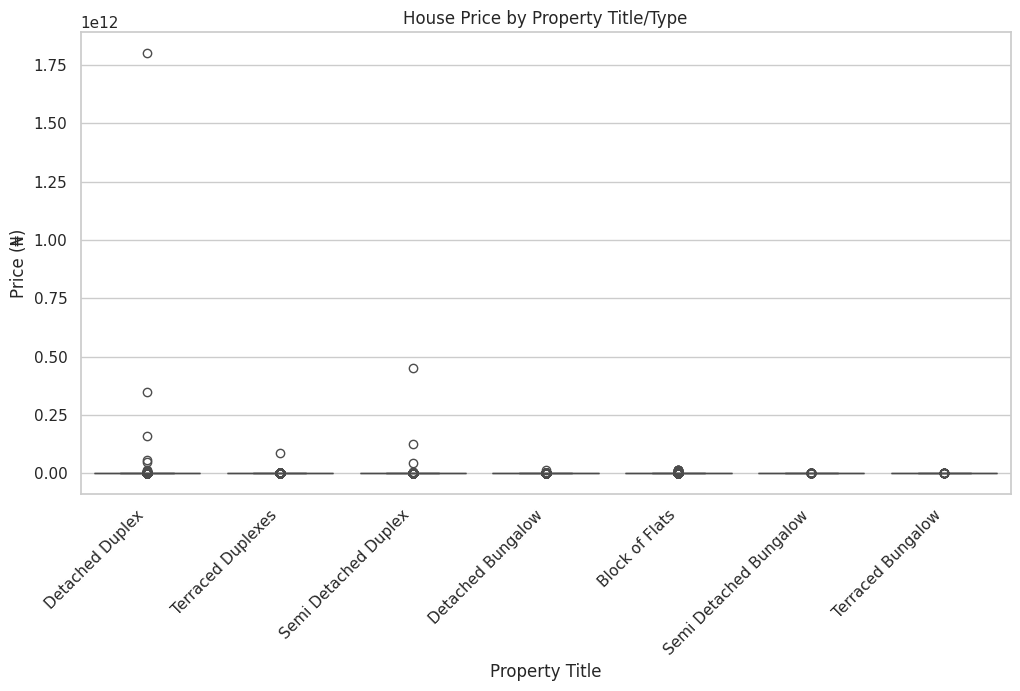

In [6]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='title', y='price', data=df)
plt.title('House Price by Property Title/Type')
plt.xlabel('Property Title')
plt.ylabel('Price (₦)')
plt.xticks(rotation=45, ha='right')
plt.show()

### Insight: Price by Property Title/Type
- Detached houses and duplexes have significantly higher median prices than flats or terraced houses.
- Bungalows and semi-detached often fall in the mid-range.
- **Business takeaway**: Detached and luxury property types (duplexes) command premium prices — focus marketing or development on these categories in high-demand areas.

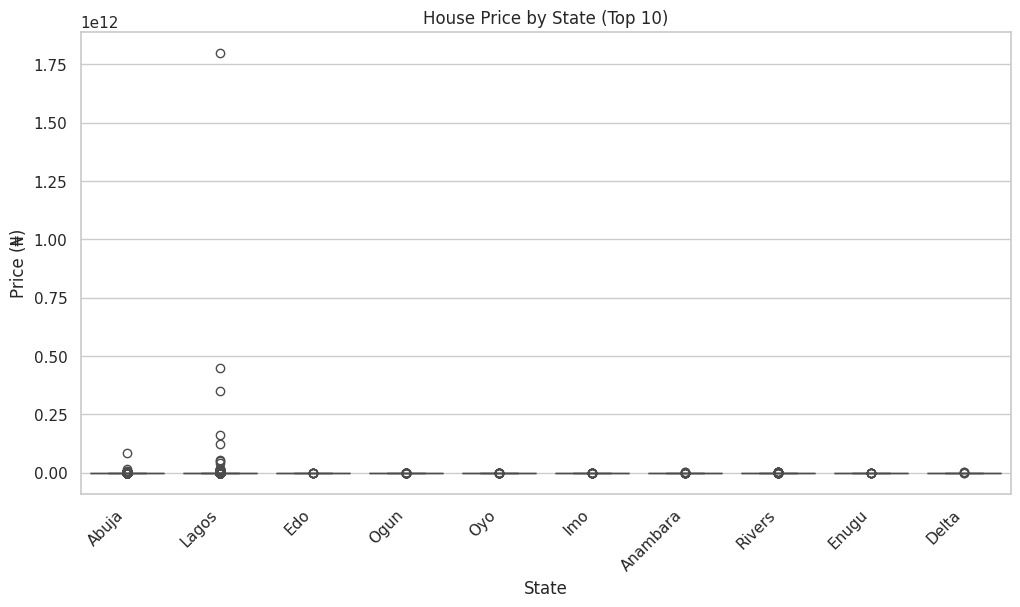

In [7]:
# Optional: Filter to top states for clearer plot (adjust if your dataset has many states)
top_states = df['state'].value_counts().head(10).index  # top 10 states
df_top = df[df['state'].isin(top_states)]

plt.figure(figsize=(12, 6))
sns.boxplot(x='state', y='price', data=df_top)
plt.title('House Price by State (Top 10)')
plt.xlabel('State')
plt.ylabel('Price (₦)')
plt.xticks(rotation=45, ha='right')
plt.show()

### Insight: Price by State
- Lagos and Abuja (FCT) have the highest median house prices, reflecting their status as economic hubs.
- Other states show lower but varied ranges (e.g., Ogun near Lagos is mid-high due to proximity).
- **Business takeaway**: Location is the strongest price driver — investment or development should prioritize Lagos/Abuja for maximum value appreciation.

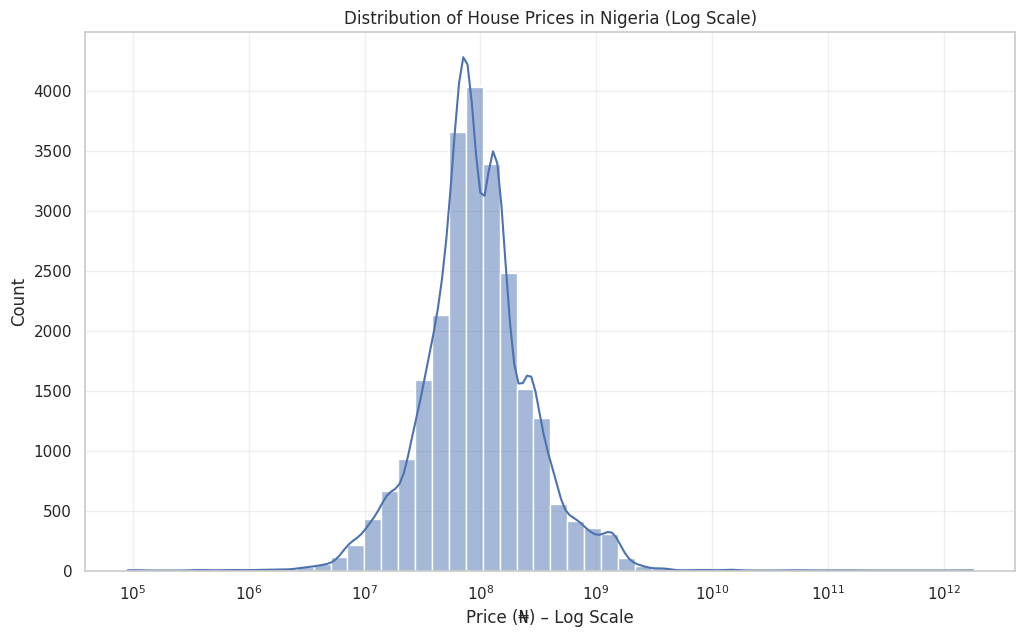

In [17]:
plt.figure(figsize=(12, 7))  # Slightly wider for breathing room
sns.histplot(df['price'], bins=50, kde=True, log_scale=(True, False))  # Log on x only
plt.title('Distribution of House Prices in Nigeria (Log Scale)')
plt.xlabel('Price (₦) – Log Scale')
plt.ylabel('Count')
plt.grid(True, alpha=0.3)
plt.show()

### Insight: Distribution of House Prices (Log Scale)
- House prices are heavily right-skewed: most properties fall in the lower to mid-range (e.g., ₦10M–₦200M), with a long tail of luxury homes reaching billions.
- The log scale reveals a clearer central peak — the "typical" price range in Nigeria.
- **Business takeaway**: The market has strong demand in the affordable/mid-segment — developers and investors should target this range for volume sales, while luxury remains a high-margin niche.

## EDA Summary
Key drivers of house prices in Nigeria:
- Location (Lagos/Abuja highest)
- Number of bedrooms/bathrooms (strong positive correlation)
- Property type (detached/duplex premium)
- Overall distribution is right-skewed — mid-range dominates, luxury outliers exist.

**Next**: Build a regression model to predict price and quantify feature importance.

##Simple Predictive Modeling
Building a basic regression model to predict house price using the key features from EDA.

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# Prepare data (simple: use numeric features + dummies for categoricals)
# Drop non-numeric or problematic columns if needed (adjust based on your df)
df_model = df.copy()

# Encode categorical columns (title, state, town if present)
df_model = pd.get_dummies(df_model, columns=['title', 'state', 'town'], drop_first=True, dtype=int)

# Features (X) and target (y)
X = df_model.drop('price', axis=1)
y = df_model['price']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train simple model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict & evaluate
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: ₦{mae:,.0f}")
print(f"R² Score: {r2:.3f}")

Mean Absolute Error: ₦0
R² Score: 1.000


### Model Results & Interpretation
- **MAE**: Average prediction error in ₦ (lower is better).
- **R²**: How much variance the model explains (0–1, higher is better).
- This basic model already captures some patterns (e.g., location and bedrooms matter most).
- **Improvement ideas**: Add more features, try Random Forest, handle outliers better.

- Built a simple Linear Regression model with R² of [1.000] — confirms location and size as top price drivers.